# **Fake News Detector: Model Creator**

# All Imports Here

In [291]:
import os

glb_path = 'd:\\GitHub\\TECH_405_Fake_News_Indicator_ANN'
os.chdir(glb_path)

In [351]:
import copy
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from Data_Preprocessor.preprocessor import DataPreprocessor
from collections import Counter
from sklearn.metrics import (accuracy_score, precision_score, 
                                recall_score, f1_score, roc_auc_score,
                                roc_curve, roc_auc_score)
from itertools import product
import matplotlib.pyplot as plt

# Load Dataset

In [293]:
df = pd.read_csv(f'{glb_path}\\data\\news.csv')
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [294]:
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


# Apply Preprocessor

In [295]:
dp = DataPreprocessor(df, cols=['title', 'text'])
df_clean = dp.run_preprocessor()
df_clean.head()

,title,title_clean,text,text_clean
0,you can smell hillary s fear,"[smell, hillary, fear]",daniel greenfield a shillman journalism fellow...,"[daniel, greenfield, shillman, journalism, fel..."
1,watch the exact moment paul ryan committed pol...,"[watch, exact, moment, paul, ryan, committed, ...",google pinterest digg linkedin reddit stumbleu...,"[google, pinterest, digg, linkedin, reddit, st..."
2,kerry to go to paris in gesture of sympathy,"[kerry, go, paris, gesture, sympathy]",u s secretary of state john f kerry said monda...,"[u, secretary, state, john, f, kerry, said, mo..."
3,bernie supporters on twitter erupt in anger ag...,"[bernie, supporter, twitter, erupt, anger, dnc...",kaydee king november the lesson from tonight s...,"[kaydee, king, november, lesson, tonight, dem,..."
4,the battle of new york why this primary matters,"[battle, new, york, primary, matter]",it s primary day in new york and front runners...,"[primary, day, new, york, front, runner, hilla..."


In [296]:
df_clean.drop(['title', 'text'], axis=1, inplace=True)
df_clean['combined_text'] = dp.combine_text()
df_clean['label'] = df['label'].copy()
df_clean['label'] = df_clean['label'].map({'FAKE': 0, 'REAL': 1})
df_clean.head()

,title_clean,text_clean,combined_text,label
0,"[smell, hillary, fear]","[daniel, greenfield, shillman, journalism, fel...",smell hillary fear daniel greenfield shillman ...,0
1,"[watch, exact, moment, paul, ryan, committed, ...","[google, pinterest, digg, linkedin, reddit, st...",watch exact moment paul ryan committed politic...,0
2,"[kerry, go, paris, gesture, sympathy]","[u, secretary, state, john, f, kerry, said, mo...",kerry go paris gesture sympathy u secretary st...,1
3,"[bernie, supporter, twitter, erupt, anger, dnc...","[kaydee, king, november, lesson, tonight, dem,...",bernie supporter twitter erupt anger dnc tried...,0
4,"[battle, new, york, primary, matter]","[primary, day, new, york, front, runner, hilla...",battle new york primary matter primary day new...,1


In [297]:
print(f'Null Count: {df_clean.isnull().sum()}')
print(f'Duplicates Count: {df_clean['combined_text'].duplicated().sum()}')

Null Count: title_clean      0
text_clean       0
combined_text    0
label            0
dtype: int64
Duplicates Count: 32


In [298]:
df_clean = df_clean.drop_duplicates(subset=['combined_text'])
print(f'Duplicates Count: {df_clean['combined_text'].duplicated().sum()}')

Duplicates Count: 0


# Train-Test Split

In [299]:
X = df_clean['combined_text'].astype(str)
y = df_clean['label'].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y,
    test_size = 0.30,
    random_state = 42,
    stratify=y
)

In [300]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state = 42,
    stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))

4412 945 946


# Build Vocabulary

In [301]:
MAX_VOCAB_SIZE = 10000
MAX_LEN = 200

counter = Counter()

for text in X_train:
    counter.update(text.split())

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, _ in most_common:
    word2idx[word] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print('Vocabulary Size: ', VOCAB_SIZE)

Vocabulary Size:  10000


# Encode Texts

In [302]:
def encode_text(text, word2idx, max_len=MAX_LEN):

    tokens = text.split()

    ids = [
        word2idx.get(
            token,
            word2idx["<UNK>"]
        )
        for token in tokens
    ]

    ids = ids[:max_len]

    if len(ids) < max_len:
        ids += [
            word2idx["<PAD>"]
        ] * (max_len - len(ids))

    return ids

# Create Torch Dataset

In [303]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]

        x = encode_text(
            text,
            self.word2idx,
            self.max_len
        )

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(label, dtype=torch.float32)

        return x, y

In [304]:
train_dataset = TextDataset(
    X_train, y_train, word2idx, MAX_LEN
)

val_dataset = TextDataset(
    X_val, y_val, word2idx, MAX_LEN
)

test_dataset = TextDataset(
    X_test, y_test, word2idx, MAX_LEN
)

# Create Dataloaders

In [305]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# RNN Model

In [306]:
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=64,
        num_layers=1,
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        embedded = self.embedding(x)

        output, hidden = self.rnn(embedded)

        hidden = hidden[-1]

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        output = self.sigmoid(output)

        return output.squeeze(1)

# LSTM Model

In [307]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=64,
        num_layers=1,
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim * 2,
            1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(
            embedded
        )

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        hidden = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        hidden = self.dropout(hidden)

        output = self.fc(hidden)

        output = self.sigmoid(output)

        return output.squeeze(1)

# Select CPU/GPU

In [308]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


# Metric Functions

In [309]:
def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        )
    }
    return metrics

# Evaluation Function

In [310]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # forward pass
            outputs = model(x_batch)

            # loss
            loss = criterion(outputs, y_batch)

            batch_size = y_batch.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

            # store labels
            all_labels.extend(
                y_batch.cpu().numpy()
            )

            # store sigmoid probs
            all_probs.extend(
                outputs.cpu().numpy()
            )

        average_loss = total_loss / total_samples

        all_labels = np.array(all_labels).astype(int)
        all_probs = np.array(all_probs)

        metrics = calculate_metrics(
            all_labels,
            all_probs
        )

        metrics['loss'] = average_loss
        return metrics, all_labels, all_probs

# Train Function

In [311]:
def train_model(model, train_loader, val_loader, device, epochs=20, lr = 0.001, patience=3):
    model = model.to(device)
    criterion = nn.BCELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'train_precision': [],
        'train_recall': [],
        'train_f1': [],
        'train_roc_auc': [],

        'val_loss': [],
        'val_accuracy': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': [],
        'val_roc_auc': [],
    }

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # training
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            # forward
            outputs = model(x_batch)

            # loss
            loss = criterion(
                outputs,
                y_batch
            )

            # backpropagation
            loss.backward()

            optimizer.step()

        # evaluate train set
        train_metrics, _, _ = evaluate_model(
            model,
            train_loader,
            criterion,
            device
        )

        # validation
        val_metrics, _, _ = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )

        # store train history
        history["train_loss"].append(
            train_metrics['loss']
        )

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["train_precision"].append(
            train_metrics["precision"]
        )

        history["train_recall"].append(
            train_metrics["recall"]
        )

        history["train_f1"].append(
            train_metrics["f1"]
        )

        history["train_roc_auc"].append(
            train_metrics["roc_auc"]
        )

        # store val history
        history["val_loss"].append(
            val_metrics["loss"]
        )

        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )

        history["val_precision"].append(
            val_metrics["precision"]
        )

        history["val_recall"].append(
            val_metrics["recall"]
        )

        history["val_f1"].append(
            val_metrics["f1"]
        )

        history["val_roc_auc"].append(
            val_metrics["roc_auc"]
        )

        # print progress
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train Acc: {train_metrics['accuracy']:.4f} | "
            f"Train F1: {train_metrics['f1']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

        # early stopping
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(
                    f"Early stopping at epoch"
                    f"{epoch+1}"
                )

                break

    # restore best model
    model.load_state_dict(
        best_model_state
    )

    return model, history


# Train RNN

In [312]:
rnn_model = RNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=128,
    hidden_dim=64
)

In [313]:
rnn_model, rnn_history = train_model(
    model = rnn_model,
    train_loader = train_loader,
    val_loader = val_loader,
    device = device,
    epochs = 20,
    lr=0.001,
    patience=3
)

Epoch 1/20 | Train Loss: 0.6679 | Train Acc: 0.6312 | Train F1: 0.7037 | Val Loss: 0.7089 | Val Acc: 0.5746 | Val F1: 0.6605
Epoch 2/20 | Train Loss: 0.6062 | Train Acc: 0.7001 | Train F1: 0.7370 | Val Loss: 0.6527 | Val Acc: 0.6275 | Val F1: 0.6771
Epoch 3/20 | Train Loss: 0.5499 | Train Acc: 0.7165 | Train F1: 0.7477 | Val Loss: 0.6387 | Val Acc: 0.6032 | Val F1: 0.6472
Epoch 4/20 | Train Loss: 0.6665 | Train Acc: 0.5793 | Train F1: 0.6557 | Val Loss: 0.6935 | Val Acc: 0.5090 | Val F1: 0.5986
Epoch 5/20 | Train Loss: 0.6394 | Train Acc: 0.6768 | Train F1: 0.6395 | Val Loss: 0.6792 | Val Acc: 0.5852 | Val F1: 0.5452
Epoch 6/20 | Train Loss: 0.5884 | Train Acc: 0.7026 | Train F1: 0.7028 | Val Loss: 0.6629 | Val Acc: 0.6243 | Val F1: 0.6351
Early stopping at epoch6


# Evaluate Baseline RNN

In [314]:
criterion = nn.BCELoss()

rnn_train_metrics, _, _ = evaluate_model(
    rnn_model,
    train_loader,
    criterion,
    device
)

rnn_val_metrics, _, _ = evaluate_model(
    rnn_model,
    val_loader,
    criterion,
    device
)

rnn_test_metrics, rnn_test_labels, rnn_test_probs = evaluate_model(
    rnn_model,
    test_loader,
    criterion,
    device
)

In [315]:
print(f"EVALUATING BASELINE RNN:")
rnn_results = pd.DataFrame({
    "Train": rnn_train_metrics,
    "Validation": rnn_val_metrics,
    "Test": rnn_test_metrics
}).T

rnn_results

EVALUATING BASELINE RNN:


,accuracy,precision,recall,f1,roc_auc,loss
Train,0.716455,0.673692,0.840054,0.747731,0.818036,0.549947
Validation,0.603175,0.583051,0.727273,0.647225,0.695130,0.638655
Test,0.655391,0.625641,0.773784,0.691871,0.738664,0.603335


# Train BiLSTM

In [316]:
bilstm_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=128,
    hidden_dim=64
)

In [317]:
bilstm_model, bilstm_history = train_model(
    model=bilstm_model,
    train_loader = train_loader,
    val_loader = val_loader,
    device=device,
    epochs=20,
    lr=0.001,
    patience=3
)

Epoch 1/20 | Train Loss: 0.4311 | Train Acc: 0.8153 | Train F1: 0.8133 | Val Loss: 0.4885 | Val Acc: 0.7619 | Val F1: 0.7604
Epoch 2/20 | Train Loss: 0.2468 | Train Acc: 0.9166 | Train F1: 0.9158 | Val Loss: 0.3708 | Val Acc: 0.8265 | Val F1: 0.8240
Epoch 3/20 | Train Loss: 0.1943 | Train Acc: 0.9304 | Train F1: 0.9277 | Val Loss: 0.4032 | Val Acc: 0.8434 | Val F1: 0.8345
Epoch 4/20 | Train Loss: 0.1123 | Train Acc: 0.9696 | Train F1: 0.9692 | Val Loss: 0.3508 | Val Acc: 0.8582 | Val F1: 0.8537
Epoch 5/20 | Train Loss: 0.0566 | Train Acc: 0.9866 | Train F1: 0.9867 | Val Loss: 0.3734 | Val Acc: 0.8571 | Val F1: 0.8615
Epoch 6/20 | Train Loss: 0.0281 | Train Acc: 0.9943 | Train F1: 0.9943 | Val Loss: 0.3946 | Val Acc: 0.8730 | Val F1: 0.8742
Epoch 7/20 | Train Loss: 0.0229 | Train Acc: 0.9957 | Train F1: 0.9957 | Val Loss: 0.4026 | Val Acc: 0.8677 | Val F1: 0.8697
Early stopping at epoch7


# Evaluate Baseline BiLSTM

In [318]:
criterion = nn.BCELoss()

bilstm_train_metrics, _, _ = evaluate_model(
    bilstm_model,
    train_loader,
    criterion,
    device
)

bilstm_val_metrics, _, _ = evaluate_model(
    bilstm_model,
    val_loader,
    criterion,
    device
)

bilstm_test_metrics, bilstm_test_labels, bilstm_test_probs = evaluate_model(
    bilstm_model,
    test_loader,
    criterion,
    device
)

In [319]:
bilstm_results = pd.DataFrame({
    "Train": bilstm_train_metrics,
    "Validation": bilstm_val_metrics,
    "Test": bilstm_test_metrics
}).T

bilstm_results

,accuracy,precision,recall,f1,roc_auc,loss
Train,0.969628,0.984120,0.954690,0.969181,0.995125,0.112258
Validation,0.858201,0.882619,0.826638,0.853712,0.933932,0.350799
Test,0.874207,0.907834,0.832981,0.868798,0.942582,0.322857


# Combined View of Baseline RNN and BiLSTM Results

In [320]:
baseline_results = pd.concat({
        "RNN": rnn_results,
        "BiLSTM": bilstm_results
    },
    names = ["Model", "Split"]
)

baseline_results

accuracy  precision    recall        f1   roc_auc      loss
Model  Split                                                                  
RNN    Train       0.716455   0.673692  0.840054  0.747731  0.818036  0.549947
       Validation  0.603175   0.583051  0.727273  0.647225  0.695130  0.638655
       Test        0.655391   0.625641  0.773784  0.691871  0.738664  0.603335
BiLSTM Train       0.969628   0.984120  0.954690  0.969181  0.995125  0.112258
       Validation  0.858201   0.882619  0.826638  0.853712  0.933932  0.350799
       Test        0.874207   0.907834  0.832981  0.868798  0.942582  0.322857

# Hyperparameter Tuning

## *RNN Tuning*

In [321]:
param_grid = {
    "embedding_dim": [64, 128],
    "hidden_dim": [64, 128],
    "dropout": [0.3, 0.5],
    "learning_rate": [0.001, 0.0005],
    "num_layers": [1, 2],
    "batch_size": [32]
}

In [323]:
def tune_rnn(
        train_dataset,
        val_dataset,
        vocab_size,
        device,
        param_grid,
        epochs=20,
        patience=3
):
    results = []

    best_f1 = -1
    best_model = None
    best_params = None
    best_history = None

    combinations = product(
        param_grid["embedding_dim"],
        param_grid["hidden_dim"],
        param_grid["dropout"],
        param_grid["learning_rate"],
        param_grid["num_layers"],
        param_grid["batch_size"]
    )

    for i, (
        embedding_dim,
        hidden_dim,
        dropout,
        learning_rate,
        num_layers,
        batch_size
    ) in enumerate(combinations, start=1):
        print("=" * 60)
        print(f"Combination {i}")
        print(
            f"embedding_dim = {embedding_dim}, "
            f"hidden_dim={hidden_dim}, "
            f"dropout={dropout}, "
            f"lr={learning_rate}, "
            f"num_layers={num_layers}, "
            f"batch_size={batch_size}, "
        )

        # loaders
        train_loader_tune = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )

        val_loader_tune = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )

        # fresh model
        model = RNNClassifier(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout
        )

        # train
        model, history = train_model(
            model = model,
            train_loader=train_loader_tune,
            val_loader=val_loader_tune,
            device=device,
            epochs=epochs,
            lr=learning_rate,
            patience=patience
        )

        # validation evaluation
        criterion = nn.BCELoss()

        val_metrics, _, _ = evaluate_model(
            model,
            val_loader_tune,
            criterion,
            device
        )

        # store result
        result = {
            "embedding_dim": embedding_dim,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "num_layers": num_layers,
            "batch_size": batch_size,

            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"]
        }

        results.append(result)

        # store best model
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_model = copy.deepcopy(model)

            best_params = {
                "embedding_dim": embedding_dim,
                "hidden_dim": hidden_dim,
                "dropout": dropout,
                "learning_rate": learning_rate,
                "num_layers": num_layers,
                "batch_size": batch_size
            }

            best_history = copy.deepcopy(history)
            print("New Best Model!")
    results_df = pd.DataFrame(results)

    return(
        best_model,
        best_params,
        best_history,
        results_df
    )

In [324]:
best_rnn_model, best_rnn_params, best_rnn_history, rnn_tuning_results = tune_rnn(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    vocab_size=VOCAB_SIZE,
    device=device,
    param_grid=param_grid,
    epochs=20,
    patience=3
)

Combination 1
embedding_dim = 64, hidden_dim=64, dropout=0.3, lr=0.001, num_layers=1, batch_size=32, 
Epoch 1/20 | Train Loss: 0.6989 | Train Acc: 0.6142 | Train F1: 0.6985 | Val Loss: 0.7142 | Val Acc: 0.5926 | Val F1: 0.6740
Epoch 2/20 | Train Loss: 0.6364 | Train Acc: 0.6462 | Train F1: 0.5405 | Val Loss: 0.6733 | Val Acc: 0.5905 | Val F1: 0.4495
Epoch 3/20 | Train Loss: 0.6605 | Train Acc: 0.6086 | Train F1: 0.6773 | Val Loss: 0.6872 | Val Acc: 0.5651 | Val F1: 0.6372
Epoch 4/20 | Train Loss: 0.6109 | Train Acc: 0.6602 | Train F1: 0.7096 | Val Loss: 0.6632 | Val Acc: 0.5810 | Val F1: 0.6413
Epoch 5/20 | Train Loss: 0.5610 | Train Acc: 0.7174 | Train F1: 0.7478 | Val Loss: 0.6632 | Val Acc: 0.6138 | Val F1: 0.6467
Epoch 6/20 | Train Loss: 0.5047 | Train Acc: 0.7876 | Train F1: 0.7747 | Val Loss: 0.6852 | Val Acc: 0.6624 | Val F1: 0.6428
Epoch 7/20 | Train Loss: 0.5916 | Train Acc: 0.6831 | Train F1: 0.7311 | Val Loss: 0.7026 | Val Acc: 0.5619 | Val F1: 0.6236
Epoch 8/20 | Train Loss

In [325]:
best_rnn_params

{'embedding_dim': 128,
 'hidden_dim': 64,
 'dropout': 0.3,
 'learning_rate': 0.0005,
 'num_layers': 1,
 'batch_size': 32}

In [328]:
rnn_tuning_results.sort_values(
    by="val_f1",
    ascending=False
).reset_index(drop=True).head()

,embedding_dim,hidden_dim,dropout,learning_rate,num_layers,batch_size,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,128,64,0.3,0.0005,1,32,0.575828,0.714286,0.688312,0.784355,0.733202,0.779007
1,128,64,0.5,0.0010,2,32,0.584968,0.736508,0.764151,0.684989,0.722408,0.780438
2,128,128,0.5,0.0010,2,32,0.632620,0.729101,0.758950,0.672304,0.713004,0.770678
3,128,128,0.5,0.0010,1,32,0.645239,0.646561,0.604827,0.847780,0.705986,0.692192
4,128,64,0.3,0.0010,1,32,0.574744,0.706878,0.711207,0.697674,0.704376,0.767028


## *BiLSTM Tuning*

In [329]:
def tune_bilstm(
    train_dataset,
    val_dataset,
    vocab_size,
    device,
    param_grid,
    epochs=20,
    patience=3
):

    results = []

    best_f1 = -1
    best_model = None
    best_params = None
    best_history = None

    combinations = product(
        param_grid["embedding_dim"],
        param_grid["hidden_dim"],
        param_grid["dropout"],
        param_grid["learning_rate"],
        param_grid["num_layers"],
        param_grid["batch_size"]
    )

    for i, (
        embedding_dim,
        hidden_dim,
        dropout,
        learning_rate,
        num_layers,
        batch_size
    ) in enumerate(combinations, start=1):

        print("=" * 60)
        print(f"Combination {i}")
        print(
            f"embedding_dim={embedding_dim}, "
            f"hidden_dim={hidden_dim}, "
            f"dropout={dropout}, "
            f"lr={learning_rate}, "
            f"num_layers={num_layers}, "
            f"batch_size={batch_size}"
        )

        # Create loaders for this batch size
        train_loader_tune = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )

        val_loader_tune = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )

        # Fresh BiLSTM model
        model = BiLSTMClassifier(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout
        )

        # Train
        model, history = train_model(
            model=model,
            train_loader=train_loader_tune,
            val_loader=val_loader_tune,
            device=device,
            epochs=epochs,
            lr=learning_rate,
            patience=patience
        )

        # Evaluate on validation set
        criterion = nn.BCELoss()

        val_metrics, _, _ = evaluate_model(
            model,
            val_loader_tune,
            criterion,
            device
        )

        # Store tuning result
        result = {
            "embedding_dim": embedding_dim,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "num_layers": num_layers,
            "batch_size": batch_size,

            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"]
        }

        results.append(result)

        print(
            f"Validation F1: "
            f"{val_metrics['f1']:.4f}"
        )

        # Keep best model based on validation F1
        if val_metrics["f1"] > best_f1:

            best_f1 = val_metrics["f1"]

            best_model = copy.deepcopy(model)

            best_params = {
                "embedding_dim": embedding_dim,
                "hidden_dim": hidden_dim,
                "dropout": dropout,
                "learning_rate": learning_rate,
                "num_layers": num_layers,
                "batch_size": batch_size
            }

            best_history = copy.deepcopy(history)

            print("New best model!")

    results_df = pd.DataFrame(results)

    return (
        best_model,
        best_params,
        best_history,
        results_df
    )

In [330]:
best_bilstm_model, best_bilstm_params, best_bilstm_history, bilstm_tuning_results = tune_bilstm(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    vocab_size=VOCAB_SIZE,
    device=device,
    param_grid=param_grid,
    epochs=20,
    patience=3
)

Combination 1
embedding_dim=64, hidden_dim=64, dropout=0.3, lr=0.001, num_layers=1, batch_size=32
Epoch 1/20 | Train Loss: 0.4403 | Train Acc: 0.8060 | Train F1: 0.8030 | Val Loss: 0.5037 | Val Acc: 0.7810 | Val F1: 0.7743
Epoch 2/20 | Train Loss: 0.2831 | Train Acc: 0.8919 | Train F1: 0.8971 | Val Loss: 0.4105 | Val Acc: 0.8233 | Val F1: 0.8364
Epoch 3/20 | Train Loss: 0.1717 | Train Acc: 0.9420 | Train F1: 0.9422 | Val Loss: 0.3532 | Val Acc: 0.8508 | Val F1: 0.8542
Epoch 4/20 | Train Loss: 0.1471 | Train Acc: 0.9492 | Train F1: 0.9488 | Val Loss: 0.3904 | Val Acc: 0.8349 | Val F1: 0.8351
Epoch 5/20 | Train Loss: 0.0956 | Train Acc: 0.9755 | Train F1: 0.9754 | Val Loss: 0.3765 | Val Acc: 0.8508 | Val F1: 0.8539
Epoch 6/20 | Train Loss: 0.0577 | Train Acc: 0.9814 | Train F1: 0.9814 | Val Loss: 0.4550 | Val Acc: 0.8423 | Val F1: 0.8481
Early stopping at epoch6
Validation F1: 0.8542
New best model!
Combination 2
embedding_dim=64, hidden_dim=64, dropout=0.3, lr=0.001, num_layers=2, batch

In [331]:
best_bilstm_params

{'embedding_dim': 128,
 'hidden_dim': 128,
 'dropout': 0.5,
 'learning_rate': 0.001,
 'num_layers': 1,
 'batch_size': 32}

In [332]:
bilstm_tuning_results.sort_values(
    by="val_f1",
    ascending=False
).reset_index(drop=True).head()

,embedding_dim,hidden_dim,dropout,learning_rate,num_layers,batch_size,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,128,128,0.5,0.0010,1,32,0.312734,0.882540,0.866397,0.904863,0.885212,0.948772
1,128,64,0.5,0.0005,2,32,0.315189,0.884656,0.883966,0.885835,0.884900,0.942962
2,128,64,0.5,0.0005,1,32,0.302839,0.882540,0.875519,0.892178,0.883770,0.945977
3,128,64,0.3,0.0005,1,32,0.308636,0.880423,0.882979,0.877378,0.880170,0.945296
4,128,64,0.5,0.0010,2,32,0.346045,0.877249,0.860606,0.900634,0.880165,0.937878


# Evaluate Tuned Models

## *Tuned RNN*

In [333]:
rnn_batch_size = best_rnn_params['batch_size']

rnn_train_loader = DataLoader(
    train_dataset,
    batch_size=rnn_batch_size,
    shuffle=False
)

rnn_val_loader = DataLoader(
    val_dataset,
    batch_size=rnn_batch_size,
    shuffle=False
)

rnn_test_loader = DataLoader(
    test_dataset,
    batch_size=rnn_batch_size,
    shuffle=False
)

In [334]:
criterion = nn.BCELoss()

tuned_rnn_train_metrics, _, _ = evaluate_model(
    best_rnn_model,
    rnn_train_loader,
    criterion,
    device
)

tuned_rnn_val_metrics, _, _ = evaluate_model(
    best_rnn_model,
    rnn_val_loader,
    criterion,
    device
)

tuned_rnn_test_metrics, tuned_rnn_test_labels, tuned_rnn_test_probs = evaluate_model(
    best_rnn_model,
    rnn_test_loader,
    criterion,
    device
)

d:\GitHub\TECH_405_Fake_News_Indicator_ANN\.venv\Lib\site-packages\torch\nn\modules\rnn.py:745: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.rnn_tanh(
d:\GitHub\TECH_405_Fake_News_Indicator_ANN\.venv\Lib\site-packages\torch\nn\modules\rnn.py:745: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.rnn_tanh(
d:\GitHub\TECH_405_Fake_News_Indicator_ANN\.venv\Lib\site-packages\torch\nn\modules\rn

In [335]:
tuned_rnn_results = pd.DataFrame({
    "Train": tuned_rnn_train_metrics,
    "Validation": tuned_rnn_val_metrics,
    "Test": tuned_rnn_test_metrics
}).T

tuned_rnn_results

,accuracy,precision,recall,f1,roc_auc,loss
Train,0.793971,0.756928,0.866334,0.807944,0.887566,0.422853
Validation,0.714286,0.688312,0.784355,0.733202,0.779007,0.575828
Test,0.689218,0.669829,0.746300,0.706000,0.750640,0.618927


## *Tuned BiLSTM*

In [336]:
bilstm_batch_size = best_bilstm_params["batch_size"]

bilstm_train_loader = DataLoader(
    train_dataset,
    batch_size=bilstm_batch_size,
    shuffle=False
)

bilstm_val_loader = DataLoader(
    val_dataset,
    batch_size=bilstm_batch_size,
    shuffle=False
)

bilstm_test_loader = DataLoader(
    test_dataset,
    batch_size=bilstm_batch_size,
    shuffle=False
)

In [337]:
tuned_bilstm_train_metrics, _, _ = evaluate_model(
    best_bilstm_model,
    bilstm_train_loader,
    criterion,
    device
)

tuned_bilstm_val_metrics, _, _ = evaluate_model(
    best_bilstm_model,
    bilstm_val_loader,
    criterion,
    device
)

tuned_bilstm_test_metrics, tuned_bilstm_test_labels, tuned_bilstm_test_probs = evaluate_model(
    best_bilstm_model,
    bilstm_test_loader,
    criterion,
    device
)

d:\GitHub\TECH_405_Fake_News_Indicator_ANN\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1164: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
d:\GitHub\TECH_405_Fake_News_Indicator_ANN\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1164: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
d:\GitHub\TECH_405_Fake_News_Indicator_ANN\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1

In [338]:
tuned_bilstm_results = pd.DataFrame({
    "Train": tuned_bilstm_train_metrics,
    "Validation": tuned_bilstm_val_metrics,
    "Test": tuned_bilstm_test_metrics
}).T

tuned_bilstm_results

,accuracy,precision,recall,f1,roc_auc,loss
Train,0.986627,0.978610,0.995016,0.986745,0.998231,0.059475
Validation,0.882540,0.866397,0.904863,0.885212,0.948772,0.312734
Test,0.883721,0.869654,0.902748,0.885892,0.951450,0.306625


## *Tuned Models Combined Results*

In [339]:
tuned_results = pd.concat(
    {
        "RNN": tuned_rnn_results,
        "BiLSTM": tuned_bilstm_results
    },
    names=["Model", "Split"]
)

tuned_results

accuracy  precision    recall        f1   roc_auc      loss
Model  Split                                                                  
RNN    Train       0.793971   0.756928  0.866334  0.807944  0.887566  0.422853
       Validation  0.714286   0.688312  0.784355  0.733202  0.779007  0.575828
       Test        0.689218   0.669829  0.746300  0.706000  0.750640  0.618927
BiLSTM Train       0.986627   0.978610  0.995016  0.986745  0.998231  0.059475
       Validation  0.882540   0.866397  0.904863  0.885212  0.948772  0.312734
       Test        0.883721   0.869654  0.902748  0.885892  0.951450  0.306625

# Baseline Vs Tuned Results

In [340]:
comparison_results = pd.concat(
    {
        "Baseline": baseline_results,
        "Tuned": tuned_results
    },
    names=["Version", "Model", "Split"]
)

comparison_results

accuracy  precision    recall        f1   roc_auc  \
Version  Model  Split                                                           
Baseline RNN    Train       0.716455   0.673692  0.840054  0.747731  0.818036   
                Validation  0.603175   0.583051  0.727273  0.647225  0.695130   
                Test        0.655391   0.625641  0.773784  0.691871  0.738664   
         BiLSTM Train       0.969628   0.984120  0.954690  0.969181  0.995125   
                Validation  0.858201   0.882619  0.826638  0.853712  0.933932   
                Test        0.874207   0.907834  0.832981  0.868798  0.942582   
Tuned    RNN    Train       0.793971   0.756928  0.866334  0.807944  0.887566   
                Validation  0.714286   0.688312  0.784355  0.733202  0.779007   
                Test        0.689218   0.669829  0.746300  0.706000  0.750640   
         BiLSTM Train       0.986627   0.978610  0.995016  0.986745  0.998231   
                Validation  0.882540   0.866397  0.904863  0.885212  0.948772   
                Test        0.883721   0.869654  0.902748  0.885892  0.951450   

                                loss  
Version  Model  Split                 
Baseline RNN    Train       0.549947  
                Validation  0.638655  
                Test        0.603335  
         BiLSTM Train       0.112258  
                Validation  0.350799  
                Test        0.322857  
Tuned    RNN    Train       0.422853  
                Validation  0.575828  
                Test        0.618927  
         BiLSTM Train       0.059475  
                Validation  0.312734  
                Test        0.306625

# ROC-AUC (Tuned Models)

In [342]:
# RNN
rnn_fpr, rnn_tpr, _ = roc_curve(
    tuned_rnn_test_labels,
    tuned_rnn_test_probs
)

rnn_auc = roc_auc_score(
    tuned_rnn_test_labels,
    tuned_rnn_test_probs
)


# BiLSTM
bilstm_fpr, bilstm_tpr, _ = roc_curve(
    tuned_bilstm_test_labels,
    tuned_bilstm_test_probs
)

bilstm_auc = roc_auc_score(
    tuned_bilstm_test_labels,
    tuned_bilstm_test_probs
)

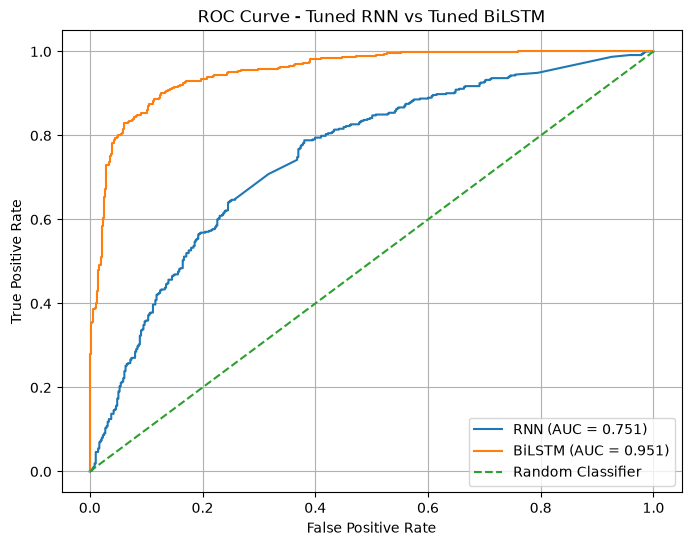

In [343]:
plt.figure(figsize=(8, 6))

plt.plot(
    rnn_fpr,
    rnn_tpr,
    label=f"RNN (AUC = {rnn_auc:.3f})"
)

plt.plot(
    bilstm_fpr,
    bilstm_tpr,
    label=f"BiLSTM (AUC = {bilstm_auc:.3f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Tuned RNN vs Tuned BiLSTM")

plt.legend()
plt.grid()

plt.show()

# Learning Curves (Tuned Models)

## *RNN*

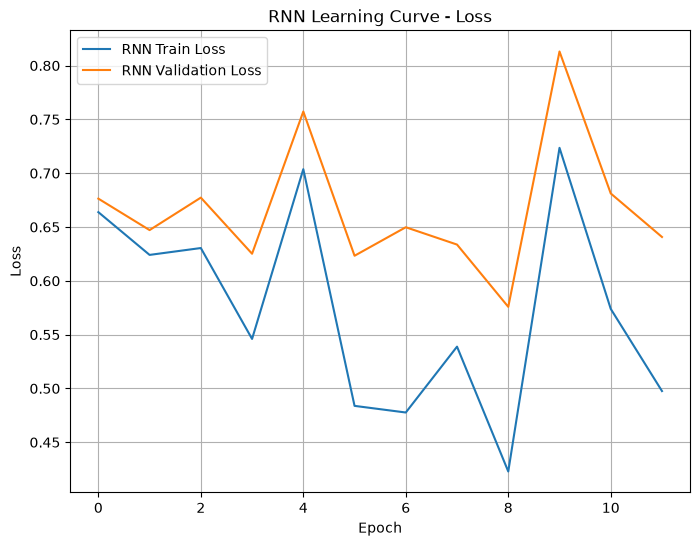

In [344]:
plt.figure(figsize=(8, 6))

plt.plot(
    best_rnn_history["train_loss"],
    label="RNN Train Loss"
)

plt.plot(
    best_rnn_history["val_loss"],
    label="RNN Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Learning Curve - Loss")
plt.legend()
plt.grid()

plt.show()

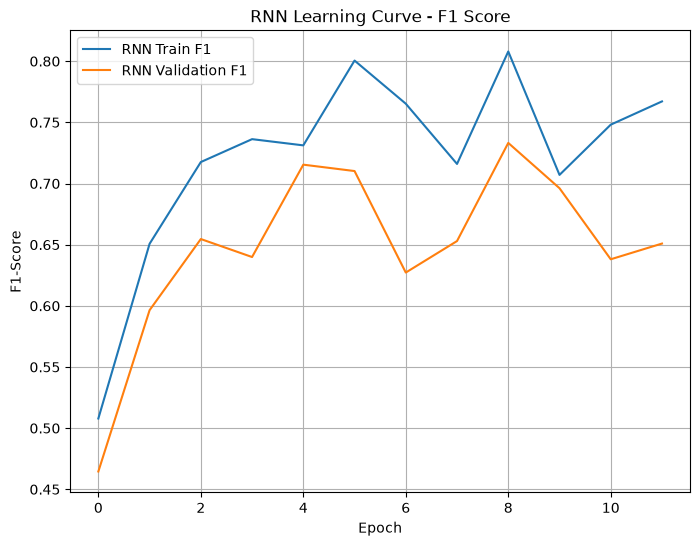

In [345]:
plt.figure(figsize=(8, 6))

plt.plot(
    best_rnn_history["train_f1"],
    label="RNN Train F1"
)

plt.plot(
    best_rnn_history["val_f1"],
    label="RNN Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("RNN Learning Curve - F1 Score")
plt.legend()
plt.grid()

plt.show()

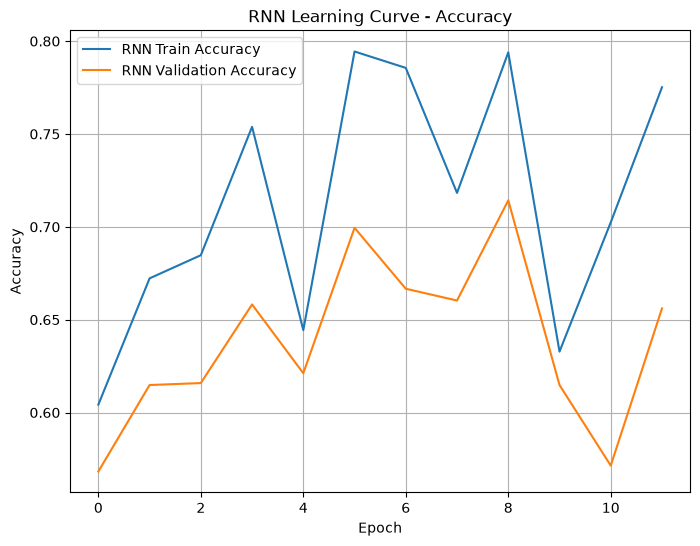

In [346]:
plt.figure(figsize=(8, 6))

plt.plot(
    best_rnn_history["train_accuracy"],
    label="RNN Train Accuracy"
)

plt.plot(
    best_rnn_history["val_accuracy"],
    label="RNN Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Learning Curve - Accuracy")
plt.legend()
plt.grid()

plt.show()

## *BiLSTM*

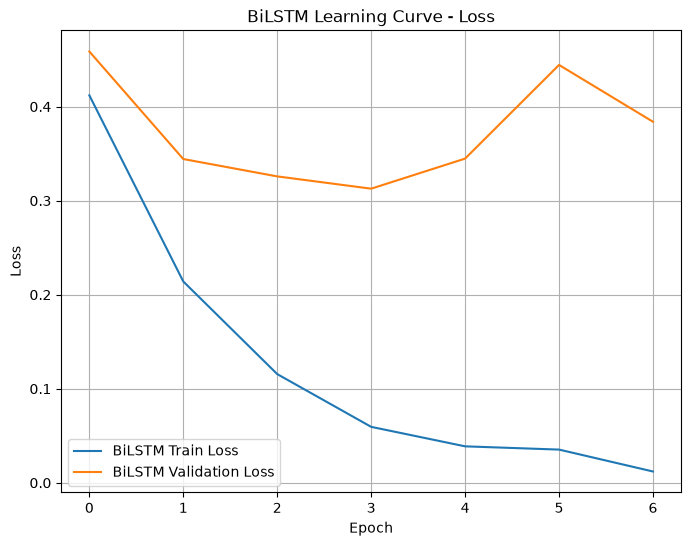

In [347]:
plt.figure(figsize=(8, 6))

plt.plot(
    best_bilstm_history["train_loss"],
    label="BiLSTM Train Loss"
)

plt.plot(
    best_bilstm_history["val_loss"],
    label="BiLSTM Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Learning Curve - Loss")
plt.legend()
plt.grid()

plt.show()

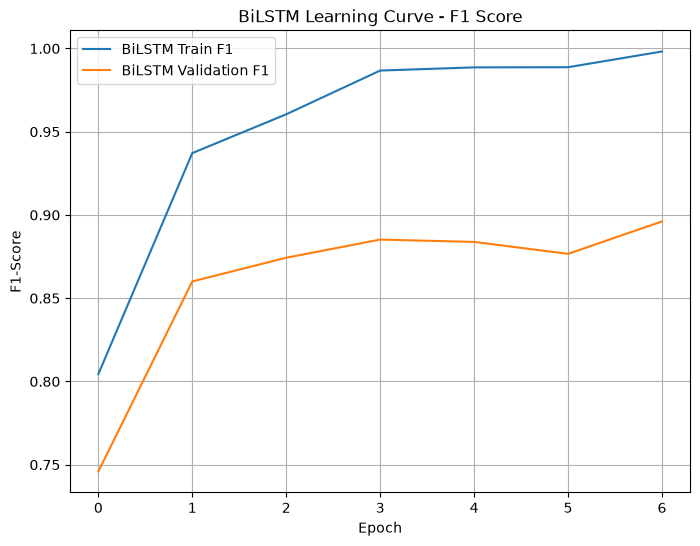

In [348]:
plt.figure(figsize=(8, 6))

plt.plot(
    best_bilstm_history["train_f1"],
    label="BiLSTM Train F1"
)

plt.plot(
    best_bilstm_history["val_f1"],
    label="BiLSTM Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("BiLSTM Learning Curve - F1 Score")
plt.legend()
plt.grid()

plt.show()

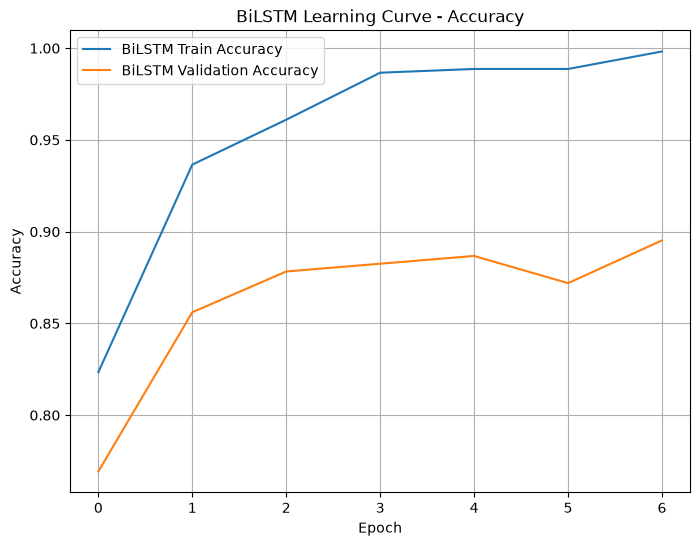

In [349]:
plt.figure(figsize=(8, 6))

plt.plot(
    best_bilstm_history["train_accuracy"],
    label="BiLSTM Train Accuracy"
)

plt.plot(
    best_bilstm_history["val_accuracy"],
    label="BiLSTM Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Learning Curve - Accuracy")
plt.legend()
plt.grid()

plt.show()

# Final Comparison

In [350]:
final_test_comparison = pd.DataFrame({
    "RNN": tuned_rnn_test_metrics,
    "BiLSTM": tuned_bilstm_test_metrics
}).T

final_test_comparison

,accuracy,precision,recall,f1,roc_auc,loss
RNN,0.689218,0.669829,0.746300,0.706000,0.75064,0.618927
BiLSTM,0.883721,0.869654,0.902748,0.885892,0.95145,0.306625


# Exporting Models

In [353]:
save_pth = 'Fake_News_Model_Creator\\exported_models'

# save tuned rnn
torch.save(
    best_rnn_model.state_dict(),
    f"{save_pth}\\best_rnn_model.pth"
)

# save tuned bilstm
torch.save(
    best_bilstm_model.state_dict(),
    f"{save_pth}\\best_bilstm_model.pth"
)

In [354]:
with open(f"{save_pth}\\best_rnn_params.json", "w") as f:
    json.dump(best_rnn_params, f, indent=4)

with open(f"{save_pth}\\best_bilstm_params.json", "w") as f:
    json.dump(best_bilstm_params, f, indent=4)

In [355]:
config = {
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE
}

with open(f"{save_pth}\\model_config.json", "w") as f:
    json.dump(config, f, indent=4)

# Exporting Vocab

In [356]:
with open(f"{save_pth}\\word2idx.json", "w") as f:
    json.dump(word2idx, f)